In [146]:
from __future__ import annotations

import operator, os, sqlite3, time
from pathlib import Path
from typing import TypedDict, List, Optional, Annotated, NotRequired, Literal

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.sqlite import SqliteSaver
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_groq import ChatGroq
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults
from dotenv import load_dotenv

def _node_start(name: str) -> float:
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] START {name}")
    return time.perf_counter()


def _node_end(name: str, started_at: float) -> None:
    elapsed = time.perf_counter() - started_at
    print(f"[{time.strftime('%Y-%m-%d %H:%M:%S')}] END {name} ({elapsed:.2f}s)")

In [147]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=3,
        max_length=6,
        description="3–6 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(..., description="Target word count for this section (120–550).")

    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False

In [148]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str
    blog_kind: Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"] = "explainer"
    constraints: List[str] = Field(default_factory=list)
    tasks: List[Task]

In [149]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)


class ImageSpec(BaseModel):
    placeholder: str = Field(..., description="e.g. [[IMAGE_1]]")
    filename: str = Field(..., description="Save under images/, e.g. qkv_flow.png")
    alt: str
    caption: str
    prompt: str = Field(..., description="Prompt to send to the image model.")
    size: Literal["1024x1024", "1024x1536", "1536x1024"] = "1024x1024"
    quality: Literal["low", "medium", "high"] = "medium"


class GlobalImagePlan(BaseModel):
    md_with_placeholders: str
    images: List[ImageSpec] = Field(default_factory=list)

In [150]:
class State(TypedDict):
    topic: str

    # routing / research
    mode: NotRequired[str]
    needs_research: NotRequired[bool]
    queries: NotRequired[List[str]]
    evidence: NotRequired[List[EvidenceItem]]

    plan: NotRequired[Plan]

    # workers
    sections: Annotated[List[tuple[int, str]], operator.add]

    # reducer/image
    merged_md: NotRequired[str]
    md_with_placeholders: NotRequired[str]
    image_specs: NotRequired[List[dict]]
    final: NotRequired[str]

In [151]:
load_dotenv(Path(".env"), override=True)

llm = ChatGoogleGenerativeAI(
    model="gemma-4-31b-it",
    google_api_key=os.environ["GOOGLE_API_KEY"],
)

In [152]:
ORCH_SYSTEM = """You are a senior technical writer and developer advocate.
Your job is to produce a highly actionable outline for a technical blog post.

Hard requirements:
- Create 5–9 sections (tasks) suitable for the topic and audience.
- Each task must include:
  1) goal (1 sentence)
  2) 3–6 bullets that are concrete, specific, and non-overlapping
  3) target word count (120–550)

Quality bar:
- Assume the reader is a developer; use correct terminology.
- Bullets must be actionable: build/compare/measure/verify/debug.
- Ensure the overall plan includes at least 2 of these somewhere:
  * minimal code sketch / MWE (set requires_code=True for that section)
  * edge cases / failure modes
  * performance/cost considerations
  * security/privacy considerations (if relevant)
  * debugging/observability tips

Grounding rules:
- Mode closed_book: keep it evergreen; do not depend on evidence.
- Mode hybrid:
  - Use evidence for up-to-date examples (models/tools/releases) in bullets.
  - Mark sections using fresh info as requires_research=True and requires_citations=True.
- Mode open_book:
  - Set blog_kind = "news_roundup".
  - Every section is about summarizing events + implications.
  - DO NOT include tutorial/how-to sections unless user explicitly asked for that.
  - If evidence is empty or insufficient, create a plan that transparently says "insufficient sources"
    and includes only what can be supported.

Output must strictly match the Plan schema.
"""

def orchestrator_node(state: State) -> dict:
    _started_at = _node_start("orchestrator")
    planner = llm.with_structured_output(Plan)

    evidence = state.get("evidence", [])
    mode = state.get("mode", "closed_book")

    plan = planner.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {mode}\n\n"
                    f"Evidence (ONLY use for fresh claims; may be empty):\n"
                    f"{[e.model_dump() for e in evidence][:16]}"
                )
            ),
        ]
    )

    _node_end("orchestrator", _started_at)
    return {"plan": plan}


In [153]:
def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task.model_dump(),
                "topic": state["topic"],
                "mode": state.get("mode", ""),
                "plan": state["plan"].model_dump(),
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            },
        )
        for task in state["plan"].tasks
    ]

In [154]:
WORKER_SYSTEM = """You are a senior technical writer and developer advocate.
Write ONE section of a technical blog post in Markdown.

Hard constraints:
- Follow the provided Goal and cover ALL Bullets in order (do not skip or merge bullets).
- Stay close to Target words (\u00b115%).
- Output ONLY the section content in Markdown (no blog title H1, no extra commentary).
- Start with a '## <Section Title>' heading.

Scope guard:
- If blog_kind == "news_roundup": do NOT turn this into a tutorial/how-to guide.
  Do NOT teach web scraping, RSS, automation, or "how to fetch news" unless bullets explicitly ask for it.
  Focus on summarizing events and implications.

Grounding policy:
- If mode == open_book:
  - Do NOT introduce any specific event/company/model/funding/policy claim unless it is supported by provided Evidence URLs.
  - For each event claim, attach a source as a Markdown link: ([Source](URL)).
  - Only use URLs provided in Evidence. If not supported, write: "Not found in provided sources."
- If requires_citations == true:
  - For outside-world claims, cite Evidence URLs the same way.
- Evergreen reasoning is OK without citations unless requires_citations is true.

Code:
- If requires_code == true, include at least one minimal, correct code snippet relevant to the bullets.

Style:
- Short paragraphs, bullets where helpful, code fences for code.
- Avoid fluff/marketing. Be precise and implementation-oriented.
"""

def worker_node(payload: dict) -> dict:
    _started_at = _node_start(f"worker:{payload['task']['title']}")

    task = Task(**payload["task"])
    plan = Plan(**payload["plan"])
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:20]
        )

    response = llm.invoke(
        [
            SystemMessage(content=WORKER_SYSTEM),
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Tone: {plan.tone}\n"
                    f"Blog kind: {plan.blog_kind}\n"
                    f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    f"Target words: {task.target_words}\n"
                    f"Tags: {task.tags}\n"
                    f"requires_research: {task.requires_research}\n"
                    f"requires_citations: {task.requires_citations}\n"
                    f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    )
    content = response.content
    if isinstance(content, list):
        content = "\n".join(
            part.get("text", "")
            for part in content
            if isinstance(part, dict) and part.get("text")
        )
    section_md = str(content).strip()

    _node_end(f"worker:{task.title}", _started_at)
    return {"sections": [(task.id, section_md)]}


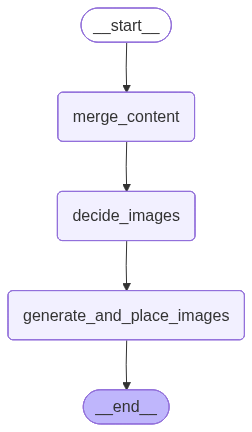

In [155]:
import re

def _output_path_for_title(title: str) -> Path:
    filename = re.sub(r'[<>:"/\\|?*]', '', title.lower().replace(" ", "_")) + ".md"
    return Path("output") / f"4_{filename}"


def merge_content(state: State) -> dict:
    _started_at = _node_start("merge_content")
    plan = state["plan"]

    ordered_sections = [md for _, md in sorted(state["sections"], key=lambda x: x[0])]
    body = "\n\n".join(ordered_sections).strip()
    merged_md = f"# {plan.blog_title}\n\n{body}\n"
    _node_end("merge_content", _started_at)
    return {"merged_md": merged_md}


DECIDE_IMAGES_SYSTEM = """You are an expert technical editor.
Decide if images/diagrams are needed for THIS blog.

Rules:
- Max 3 images total.
- Each image must materially improve understanding (diagram/flow/table-like visual).
- Insert placeholders exactly: [[IMAGE_1]], [[IMAGE_2]], [[IMAGE_3]].
- If no images needed: md_with_placeholders must equal input and images=[].
- Avoid decorative images; prefer technical diagrams with short labels.
Return strictly GlobalImagePlan.
"""

def decide_images(state: State) -> dict:
    _started_at = _node_start("decide_images")
    planner = llm.with_structured_output(GlobalImagePlan)
    merged_md = state["merged_md"]
    plan = state["plan"]

    messages = [
        SystemMessage(content=DECIDE_IMAGES_SYSTEM),
        HumanMessage(
            content=(
                f"Blog kind: {plan.blog_kind}\n"
                f"Topic: {state['topic']}\n\n"
                "Insert placeholders + propose image prompts.\n\n"
                f"{merged_md}"
            )
        ),
    ]

    for attempt in range(1, 11):
        image_plan = planner.invoke(messages)
        image_specs = [img.model_dump() for img in image_plan.images]

        if image_specs:
            print(f"Image planner returned {len(image_specs)} image spec(s) on attempt {attempt}.")
            _node_end("decide_images", _started_at)
            return {
                "md_with_placeholders": image_plan.md_with_placeholders,
                "image_specs": image_specs,
            }

        if attempt < 10:
            print(f"Image planner returned empty image_specs on attempt {attempt}; waiting 30 seconds before retrying with same input.")
            time.sleep(30)

    _node_end("decide_images", _started_at)
    raise RuntimeError("Image planner returned empty image_specs after 10 attempts.")


def _pollinations_generate_image_bytes(prompt: str) -> bytes:
    from urllib.parse import quote
    import requests

    api_key = os.environ.get("POLLINATIONS_API_KEY")
    if not api_key:
        raise RuntimeError("POLLINATIONS_API_KEY is not set.")

    url = f"https://gen.pollinations.ai/image/{quote(prompt)}"
    response = requests.get(
        url,
        params={"key": api_key, "model": "flux"},
        timeout=120,
    )
    response.raise_for_status()
    return response.content


def generate_and_place_images(state: State) -> dict:
    _started_at = _node_start("generate_and_place_images")
    plan = state["plan"]
    md = state.get("md_with_placeholders") or state["merged_md"]
    image_specs = state.get("image_specs", []) or []

    output_path = _output_path_for_title(plan.blog_title)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    if not image_specs:
        output_path.write_text(md, encoding="utf-8")
        _node_end("generate_and_place_images", _started_at)
        return {"final": md}

    images_dir = output_path.parent / "images"
    images_dir.mkdir(exist_ok=True)

    for spec in image_specs:
        placeholder = spec["placeholder"]
        filename = spec["filename"]
        out_path = images_dir / filename

        if not out_path.exists():
            try:
                img_bytes = _pollinations_generate_image_bytes(spec["prompt"])
                out_path.write_bytes(img_bytes)
            except Exception as e:
                prompt_block = (
                    f"> **[IMAGE GENERATION FAILED]** {spec.get('caption','')}\n>\n"
                    f"> **Alt:** {spec.get('alt','')}\n>\n"
                    f"> **Prompt:** {spec.get('prompt','')}\n>\n"
                    f"> **Error:** {e}\n"
                )
                md = md.replace(placeholder, prompt_block)
                continue

        img_md = f"![{spec['alt']}](images/{filename})\n*{spec['caption']}*"
        md = md.replace(placeholder, img_md)

    output_path.write_text(md, encoding="utf-8")
    _node_end("generate_and_place_images", _started_at)
    return {"final": md}


reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()

reducer_subgraph


In [156]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 3–10 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    _started_at = _node_start("router")
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    _node_end("router", _started_at)
    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    return "research" if state["needs_research"] else "orchestrator"

In [157]:
def _tavily_search(query: str, max_results: int = 5) -> List[dict]:
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized


RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    _started_at = _node_start("research")
    queries = state.get("queries", []) or []
    max_results = 6

    raw_results: List[dict] = []
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        _node_end("research", _started_at)
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    _node_end("research", _started_at)
    return {"evidence": list(dedup.values())}

In [158]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

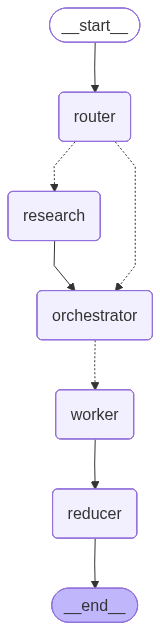

In [159]:
checkpoint_db = Path("output/langgraph_checkpoints.sqlite")
checkpoint_db.parent.mkdir(parents=True, exist_ok=True)
checkpoint_conn = sqlite3.connect(str(checkpoint_db), check_same_thread=False)
checkpointer = SqliteSaver(checkpoint_conn)
checkpointer.setup()
app = g.compile(checkpointer=checkpointer)

app

In [160]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "sections": [],
            "merged_md": "",
            "md_with_placeholders": "",
            "image_specs": [],
        },
        config={"configurable": {"thread_id": "1"}},
    )
    return out

In [161]:
#run("Write a blog on Open Source LLMs in 2026")
run("State of Multimodal LLMs in 2026")

[2026-06-13 22:43:32] START router
[2026-06-13 22:43:35] END router (3.57s)
[2026-06-13 22:43:35] START research
[2026-06-13 22:45:25] END research (109.80s)
[2026-06-13 22:45:25] START orchestrator
[2026-06-13 22:46:00] END orchestrator (34.68s)
[2026-06-13 22:46:00] START worker:The Multimodal Landscape in 2026
[2026-06-13 22:46:00] START worker:The Transition to Multimodal Agents
[2026-06-13 22:46:00] START worker:Measuring Multimodal Intelligence: Benchmarks in 2026
[2026-06-13 22:46:00] START worker:Architectural Evolutions: Beyond the Transformer
[2026-06-13 22:46:00] START worker:Developer Implementation and Ecosystem
[2026-06-13 22:47:02] END worker:The Multimodal Landscape in 2026 (62.46s)
[2026-06-13 22:47:30] END worker:The Transition to Multimodal Agents (90.66s)
[2026-06-13 22:47:41] END worker:Measuring Multimodal Intelligence: Benchmarks in 2026 (100.84s)
[2026-06-13 22:47:56] END worker:Developer Implementation and Ecosystem (115.94s)
[2026-06-13 22:48:25] END worker:Ar

{'topic': 'State of Multimodal LLMs in 2026',
 'mode': 'open_book',
 'needs_research': True,
 'queries': ['current state of Multimodal LLMs in 2026',
  'latest multimodal LLM benchmarks 2026',
  'recent breakthroughs in multimodal LLM architectures 2026',
  'most advanced multimodal LLM models available in 2026',
  'multimodal LLM applications and industry trends 2026'],
 'evidence': [EvidenceItem(title='LLM Research Papers: The 2026 List (January to May)', url='https://magazine.sebastianraschka.com/p/llm-research-papers-2026-part1', published_at=None, snippet='Architecture work goes beyond making transformers larger. There is a lot of work around hybrid architectures (for example, Nemotron 3, and Arcee Trinity), state space layers (Nemotron 3 and Mamba-3). Nemotron 3 alternates between regular attention layers and Mamba-2 (state space model) layers to be more efficient at long contexts.', source=None),
  EvidenceItem(title='Large Language Models: What You Need to Know in 2026 | HatchW

In [ ]:
# Run the cells below - only to resume the graph from reducer node
# This is only for debugging - not needed for normal execution
# Read/list checkpoints from SQLite for thread_id=1
print("checkpoint_db:", checkpoint_db)
thread_config = {"configurable": {"thread_id": "1"}}

for i, state_snapshot in enumerate(app.get_state_history(thread_config)):
    print("index:", i)
    print("next:", state_snapshot.next)
    print("checkpoint_id:", state_snapshot.config["configurable"].get("checkpoint_id"))
    print("metadata:", state_snapshot.metadata)
    print("state_keys:", list((state_snapshot.values or {}).keys()))
    print("-")

In [ ]:
# Read reducer checkpoint from SQLite and resume thread_id=1
# This reruns the reducer subgraph from merge_content onward.
thread_config = {"configurable": {"thread_id": "1"}}
reducer_snapshot = next(
    snapshot
    for snapshot in app.get_state_history(thread_config)
    if snapshot.next == ("reducer",)
)
print("Resuming checkpoint_id:", reducer_snapshot.config["configurable"].get("checkpoint_id"))

# Commented out to prevent uneccesary execution. Uncomment and run if debugging
#out = app.invoke(None, config=reducer_snapshot.config)
#out